In [30]:

import matplotlib.pyplot as plt
import torch #usada para machine learning y deep learning.
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np


# Manejo de datos

El manejo de datos suele representar una parte importante del código necesario para realizar aprendizaje automático. Antes de entrenar un modelo, necesitamos preparar los datos en un formato compatible con el entrenamiento y la evaluación.

Normalmente no entrenamos con todo el conjunto de datos al mismo tiempo, porque tardaría demasiado. En su lugar, entrenamos y evaluamos por lotes (*batches*), donde cada lote contiene una pequeña muestra de los datos. El entrenamiento se realiza en múltiples iteraciones, usando una muestra aleatoria diferente en cada iteración.

El objetivo principal de construir un modelo (de clasificación o regresión) es hacer predicciones sobre datos no vistos. A esto se le llama generalización. Por ello, debemos dividir los datos en entrenamiento y prueba. Si accidentalmente entrenamos con los datos de prueba, el modelo parecerá funcionar mejor, pero no sería una evaluación real de su capacidad de generalización.


Como ejemplo, utilizaremos el conjunto de datos MNIST, que contiene imágenes de números escritos a mano junto con sus etiquetas correspondientes. La tarea consiste en predecir qué número representa una imagen no vista y así entrenar un modelo de reconocimiento de escritura manuscrita.

Este es un conjunto de datos estándar disponible en PyTorch y ya viene dividido en entrenamiento y prueba.


In [31]:
conjunto_entrenamiento = datasets.MNIST('files/', train=True, download=True,
                             transform=transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))
conjunto_prueba = datasets.MNIST('files/', train=False, download=True,
                             transform=transforms.Compose([
                               transforms.ToTensor(),
                               transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ]))

Esto nos proporciona los conjuntos de entrenamiento y prueba de imágenes (datos) junto con sus etiquetas correspondientes (targets).


In [32]:
conjunto_entrenamiento

Dataset MNIST
    Number of datapoints: 60000
    Root location: files/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

Un tensor es una estructura para guardar números en forma de arreglo.

- Una imagen pude ser un tensor con: [canales, alto, ancho]

En redes neuronales, los datos, pesos, salidas y errores se manejan como tensores porque PyTorch puede hacer operaciones matemáticas rápidas con ellos.

In [33]:
print(conjunto_entrenamiento.data.shape)
print(conjunto_prueba.data.shape)
print(conjunto_entrenamiento.targets.shape)
print(conjunto_prueba.targets.shape)
print(conjunto_prueba.data.dtype)
print(conjunto_prueba.targets.dtype)


torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
torch.Size([60000])
torch.Size([10000])
torch.uint8
torch.int64


Observa la forma (*shape*) y el tipo de dato de los conjuntos.

Para pasar los datos al modelo, utilizaremos la función `DataLoader`.


In [34]:
tamano_lote_entrenamiento = 64
tamano_lote_prueba = 1000

cargador_entrenamiento = DataLoader( conjunto_entrenamiento, batch_size=tamano_lote_entrenamiento,shuffle=True,)

cargador_prueba = DataLoader( conjunto_prueba, batch_size=tamano_lote_prueba, shuffle=True)


Los `DataLoader` pueden usarse para generar una submuestra iterando sobre ellos.


In [35]:
ejemplos = enumerate(cargador_entrenamiento)
indice_lote, (datos_ejemplo, etiquetas_ejemplo) = next(ejemplos)
print(datos_ejemplo.shape)
print(datos_ejemplo.dtype)
print(etiquetas_ejemplo.shape)
print(etiquetas_ejemplo.dtype)


torch.Size([64, 1, 28, 28])
torch.float32
torch.Size([64])
torch.int64


Los ejemplos de prueba tienen 1000 muestras de 28x28 píxeles. Observa que `DataLoader` ha añadido una dimensión y cambiado el tipo de dato para hacerlo compatible con los modelos de PyTorch.

Los ejemplos de entrenamiento tienen la misma forma, pero solo 64 muestras.

Podemos mostrar los primeros ejemplos para ver cómo se ven y compararlos con sus etiquetas.


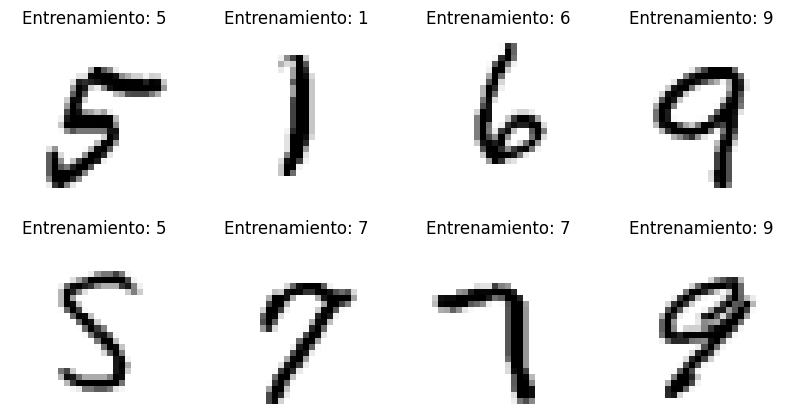

In [36]:
ejemplos = enumerate(cargador_entrenamiento)
indice_lote, (datos_ejemplo, etiquetas_ejemplo) = next(ejemplos)
figura, ejes = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))
ejes = ejes.flatten()
for eje, imagen, etiqueta in zip(ejes,datos_ejemplo,etiquetas_ejemplo):
    eje.set_axis_off()
    eje.imshow(imagen[0], cmap=plt.cm.gray_r, interpolation="nearest")
    eje.set_title("Entrenamiento: %i" % etiqueta)
  

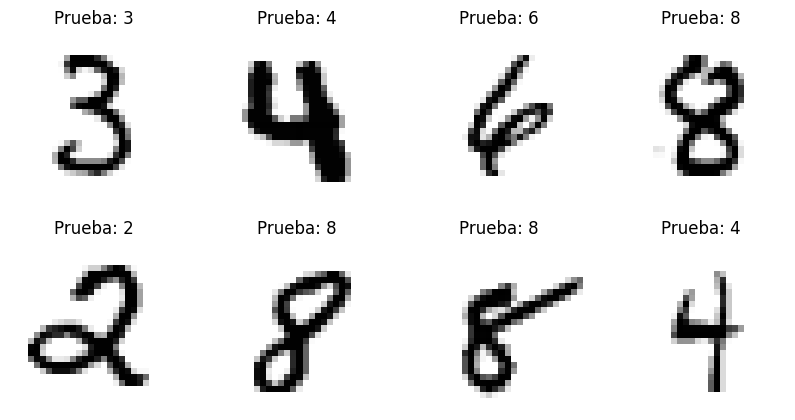

In [37]:
ejemplos = enumerate(cargador_prueba)
indice_lote, (datos_ejemplo, etiquetas_ejemplo) = next(ejemplos)
figura, ejes = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))
ejes = ejes.flatten()
for eje, imagen, etiqueta in zip(ejes,datos_ejemplo,etiquetas_ejemplo):
    eje.set_axis_off()
    eje.imshow(imagen[0], cmap=plt.cm.gray_r, interpolation="nearest")
    eje.set_title("Prueba: %i" % etiqueta)

# Ahora construyamos algunos modelos


Primero necesitamos cargar algunas herramientas adicionales de PyTorch.


In [38]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


Aplanaremos las imágenes para que cada una sea un tensor 1D (¿es una buena idea para imágenes?). Por ello, queremos saber cuántos elementos tendrá ese tensor 1D.


In [39]:
tamano_imagen = conjunto_entrenamiento.data.shape[1:]
tamano_capa_entrada =np.prod(tamano_imagen)
tamano_capa_entrada

np.int64(784)

Como trabajamos en base 10, sabemos que existen 10 clases posibles a las que puede pertenecer cada imagen.


In [40]:
numero_clases = 10

Ahora definiremos una clase que describirá nuestro modelo.

Heredará métodos y propiedades de `nn.Module`, que incluye muchas utilidades ya implementadas.


In [41]:
class RedNeuronal(nn.Module): # Hereda de nn.Module, que es la clase base para todos los módulos de redes neuronales.
    def __init__(self): # Se ejecuta cuando se inicializa la clase.
        super().__init__() # Inicializa los métodos y propiedades de la clase base Module.
        
        # Las capas se definen con el enfoque secuencial, lo que simplifica la estructura.
        self.clasificador = nn.Sequential(
                nn.Linear(tamano_capa_entrada, 500), # Capa oculta
                nn.ReLU(),
                nn.Linear(500, 500), # Capa oculta
                nn.Linear(500, numero_clases), # Capa de salida, porque es la última capa.
            )
        

    def forward(self, entrada): # Este método se usa para la propagación hacia adelante de la red.
        entrada = entrada.view(-1,tamano_capa_entrada)    # Primero se reestructuran todas las imágenes. 
        entrada = self.clasificador(entrada)             # Después se aplican las capas del clasificador. 
        return F.log_softmax(entrada,dim=0)      # Finalmente se devuelven probabilidades para cada clase usando la función softmax.
    
    

A continuación se muestra un modelo idéntico, pero definido sin usar el enfoque secuencial.


In [42]:
class RedNeuronal(nn.Module): # Hereda de nn.Module, que es la clase base para todos los módulos de redes neuronales.
    def __init__(self): # Se ejecuta cuando se inicializa la clase.
        super().__init__() # Inicializa los métodos y propiedades de la clase base Module.
        
        # Las capas se definen individualmente y luego se llaman por separado en el método forward.
        self.capa_lineal_1 = nn.Linear(tamano_capa_entrada, 500) # Capa oculta
        self.capa_lineal_2 = nn.Linear(500, numero_clases) # Capa de salida, porque es la última capa.
        

    def forward(self, entrada): # Este método se usa para la propagación hacia adelante de la red.
        entrada = entrada.view(-1,tamano_capa_entrada)    # Primero se reestructuran todas las imágenes. 
        entrada = self.capa_lineal_1(entrada)             # Después se aplica la primera capa. 
        entrada = self.capa_lineal_2(entrada)             # Después se aplica la segunda capa. 
        return F.log_softmax(entrada,dim=0)      # Finalmente se devuelven probabilidades para cada clase usando la función softmax.
    
    

Ahora podemos inicializar el modelo.


In [43]:
modelo = RedNeuronal()


Para realizar una propagación hacia adelante (*forward pass*), simplemente pasamos un lote de muestras al modelo (esto usa el método `forward()`).


In [44]:
indice_lote, (datos, etiqueta_objetivo) = next(enumerate(cargador_entrenamiento))
salida = modelo(datos)
salida[0]

tensor([-4.1609, -4.2437, -4.3896, -3.8099, -4.4069, -4.5447, -3.8775, -4.0718,
        -4.2914, -4.2086], grad_fn=<SelectBackward0>)

Esto nos da las probabilidades de que cada imagen pertenezca a cada clase.

Ahora debemos encontrar el número con mayor probabilidad para cada imagen y compararlo con las etiquetas reales.


In [45]:
_, predicho = torch.max(salida, 1)
predicho

tensor([3, 7, 2, 0, 2, 4, 6, 4, 2, 9, 8, 9, 1, 2, 5, 1, 9, 9, 0, 3, 3, 1, 6, 1,
        4, 4, 9, 7, 0, 9, 6, 7, 0, 2, 2, 8, 8, 4, 1, 7, 9, 5, 4, 0, 0, 0, 3, 9,
        7, 9, 3, 6, 3, 0, 1, 2, 6, 0, 6, 2, 2, 1, 6, 8])

Scikit-learn tiene una función útil para evaluar qué tan buenas son las predicciones mediante una matriz de confusión.


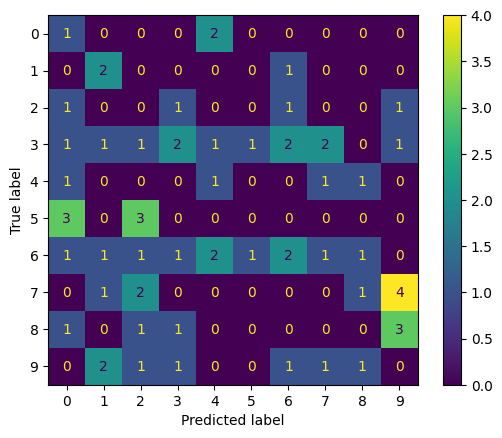

In [46]:
from sklearn import metrics
visualizacion = metrics.ConfusionMatrixDisplay.from_predictions(etiqueta_objetivo, predicho)

Esta matriz de confusión muestra que el modelo todavía no está clasificando bien los dígitos, porque los aciertos deberían concentrarse en la diagonal principal, donde la etiqueta real coincide con la etiqueta predicha. Sin embargo, en la gráfica los valores están muy dispersos fuera de esa diagonal, lo que indica muchos errores de clasificación. Por ejemplo, en la fila del dígito 8, el modelo clasificó varios ochos reales como 0, 1, 2, 3 o 4, y no logró reconocerlos correctamente como 8. Esto significa que la red neuronal aún no ha aprendido patrones suficientes de las imágenes y sus predicciones siguen siendo cercanas al azar.

Como era de esperarse, una red neuronal completamente aleatoria y sin entrenar no se ajusta bien a nuestros datos.
¡Necesitamos entrenarla!

Usaremos la pérdida de entropía cruzada (*cross entropy*), común en clasificadores, y el optimizador Adam, un algoritmo adaptativo muy utilizado en redes neuronales.


In [47]:
%%time
criterio = nn.NLLLoss()  #Negative Log Likelihood Loss.
optimizador = optim.Adam(modelo.parameters(), lr=3e-4) # Se usa una tasa de aprendizaje de 3e-4: ni demasiado grande ni demasiado pequeña.

# Se itera sobre cada lote; es decir, una pasada completa por todo el conjunto de datos.
# Esto se conoce como una época de entrenamiento.
for indice_lote, (datos, etiqueta_objetivo) in enumerate(cargador_entrenamiento):

    modelo.train() # IMPORTANTE: asegurar que el modelo esté en modo de entrenamiento.
    optimizador.zero_grad() # Reinicia los gradientes antes del cálculo.
    salida = modelo(datos) # Propagación hacia adelante del modelo. 
    perdida = criterio(salida, etiqueta_objetivo) # Calcula la función de pérdida a partir de la propagación hacia adelante.
    perdida.backward() # Usa la pérdida para realizar retropropagación y obtener los gradientes de los pesos.
    optimizador.step() # Actualiza los pesos del modelo para mejorar el ajuste.
    
    

CPU times: total: 2min 1s
Wall time: 32.1 s


Ahora evaluemos recorriendo el conjunto de prueba y comparando contra las etiquetas reales.


In [48]:


perdida_prueba = 0
correctos = 0
arreglo_predicciones = np.array([])
arreglo_etiquetas = np.array([])

modelo.eval() # IMPORTANTE: cambiar a modo de evaluación, ya que modifica algunos comportamientos.
with torch.no_grad(): # Desactiva el cálculo de gradientes porque ya no se está entrenando.
    for datos, etiqueta_objetivo in cargador_prueba:
        salida = modelo(datos)
        prediccion = salida.data.max(1, keepdim=True)[1]
        correctos += prediccion.eq(etiqueta_objetivo.data.view_as(prediccion)).sum()
        arreglo_predicciones = np.append(arreglo_predicciones,prediccion)
        arreglo_etiquetas = np.append(arreglo_etiquetas,etiqueta_objetivo)
        
correctos/len(cargador_prueba.dataset)     

tensor(0.9061)

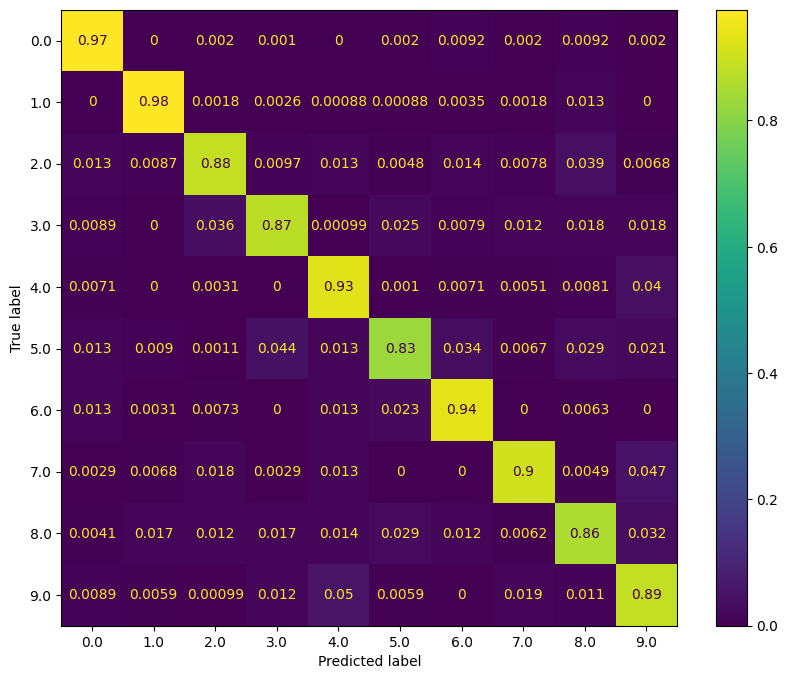

In [49]:
visualizacion = metrics.ConfusionMatrixDisplay.from_predictions(arreglo_etiquetas, arreglo_predicciones,normalize='true')
figura = plt.gcf()
figura.set_figheight(8)
figura.set_figwidth(10)

97% fueron correctamente clasificados como 0
1.1% fueron confundidos con 6
0.7% con 7
errores mínimos con otros números

De todos los dígitos reales 2:

86% fueron correctamente clasificados como 2
6.2% fueron confundidos con 8
algunos con 3 o 6

¡Más del 90% de exactitud y la matriz de confusión se ve bien!


# Reto: ¿cómo podrías superar la exactitud anterior?























¿Cómo podrías hacerlo?
- ¿Cambiando la arquitectura del modelo?
- ¿Usa funciones de activación diferentes? (por ejemplo `nn.ReLU`)
- ¿Modificando el optimizador?
- ¿Entrenando durante múltiples épocas?


In [50]:
nn.ReLU?

Init signature: nn.ReLU(inplace: bool = False) -> None
Docstring:     
Applies the rectified linear unit function element-wise.

:math:`\text{ReLU}(x) = (x)^+ = \max(0, x)`

Args:
    inplace: can optionally do the operation in-place. Default: ``False``

Shape:
    - Input: :math:`(*)`, where :math:`*` means any number of dimensions.
    - Output: :math:`(*)`, same shape as the input.

.. image:: ../scripts/activation_images/ReLU.png

Examples::

    >>> m = nn.ReLU()
    >>> input = torch.randn(2)
    >>> output = m(input)


  An implementation of CReLU - https://arxiv.org/abs/1603.05201

    >>> m = nn.ReLU()
    >>> input = torch.randn(2).unsqueeze(0)
    >>> output = torch.cat((m(input), m(-input)))
Init docstring: Initialize internal Module state, shared by both nn.Module and ScriptModule.
File:           c:\users\jessan\desktop\almacenes_mineria_datos\github\redes_neuronales\.venv\lib\site-packages\torch\nn\modules\activation.py
Type:           type
Subclasses:     ReLU6

## Define tu modelo


In [51]:
class RedNeuronal(nn.Module): # Hereda de nn.Module, que es la clase base para todos los módulos de redes neuronales.
    def __init__(self): # Se ejecuta cuando se inicializa la clase.
        super().__init__() # Inicializa los métodos y propiedades de la clase base Module.
        
        # Las capas se definen con el enfoque secuencial, lo que simplifica la estructura.
        self.clasificador = nn.Sequential(
                nn.Linear(tamano_capa_entrada, 500), # Capa oculta
                nn.BatchNorm1d(500),
                nn.ReLU(inplace=True),
                nn.Linear(500, 500), # Capa oculta
                nn.BatchNorm1d(500),
                nn.ReLU(inplace=True),
                nn.Linear(500, numero_clases), # Capa de salida, porque es la última capa.
            )

    def forward(self, entrada): # Este método se usa para la propagación hacia adelante de la red.
        entrada = entrada.view(-1,tamano_capa_entrada)    # Primero se reestructuran todas las imágenes. 
        entrada = self.clasificador(entrada)             # Después se aplican las capas del clasificador. 
        return F.log_softmax(entrada,dim=0)      # Finalmente se devuelven probabilidades para cada clase usando la función softmax.
    
    

## Define tu función de pérdida, inicializa tu modelo y un optimizador


In [52]:
modelo = RedNeuronal()
criterio = nn.NLLLoss()
optimizador = optim.Adam(modelo.parameters(), lr=3e-4) # Se usa una tasa de aprendizaje de 3e-4: ni demasiado grande ni demasiado pequeña.


La tasa de aprendizaje (learning rate) es un valor que controla qué tan grandes son los cambios que hace el optimizador en los pesos del modelo.

| Optimizador | Cómo funciona | Ventaja principal |
|---|---|---|
| SGD | Actualiza los pesos usando directamente el gradiente del error. | Es simple y fácil de entender. |
| SGD con Momentum | Usa el gradiente actual y también el impulso de actualizaciones anteriores. | Entrena de forma más estable que SGD. |
| Adam | Ajusta automáticamente la tasa de aprendizaje para cada peso. | Suele dar buenos resultados con poco ajuste manual. |
| RMSprop | Modifica la tasa de aprendizaje según los gradientes recientes. | Funciona bien cuando los gradientes cambian mucho. |
| AdamW | Variante de Adam que agrega mejor regularización con `weight_decay`. | Ayuda a reducir el sobreajuste. |

## Entrena tu modelo
Itera sobre cada lote; una pasada completa por todo el conjunto de entrenamiento se conoce como una época de entrenamiento.


In [53]:
%%time

# Se itera sobre cada lote; es decir, una pasada completa por todo el conjunto de datos.
# Esto se conoce como una época de entrenamiento.
for indice_lote, (datos, etiqueta_objetivo) in enumerate(cargador_entrenamiento):

    modelo.train()
    optimizador.zero_grad() #permite  borrar gradientes viejos, qué tanto y hacia dónde debe cambiar cada peso para reducir el error.
    salida = modelo(datos)
    perdida = criterio(salida, etiqueta_objetivo)
    perdida.backward() # En una red neuronal, se usa después de calcular la pérdida:
    optimizador.step() #sirve para actualizar los pesos del modelo usando los gradientes que ya se calcularon con


CPU times: total: 3min 13s
Wall time: 1min 4s


## Evalúa el rendimiento de tu modelo
Itera sobre cada lote del conjunto de prueba para obtener la exactitud y generar arreglos con etiquetas reales y predichas.


In [54]:
exactitud_prueba = []
exactitud_entrenamiento = []
# Evaluar el modelo:
modelo.eval()
perdida_prueba = 0
correctos = 0
arreglo_predicciones = np.array([])
arreglo_etiquetas = np.array([])
with torch.no_grad():
    for datos, etiqueta_objetivo in cargador_prueba:
        salida = modelo(datos)
        prediccion = salida.data.max(1, keepdim=True)[1]
        correctos += prediccion.eq(etiqueta_objetivo.data.view_as(prediccion)).sum()
        arreglo_predicciones = np.append(arreglo_predicciones,prediccion)
        arreglo_etiquetas = np.append(arreglo_etiquetas,etiqueta_objetivo)
        
correctos/len(cargador_prueba.dataset)     

tensor(0.9730)

El modelo clasificó correctamente el 97.27% de las imágenes del conjunto de prueba

## Grafica la matriz de confusión
Usa los arreglos de etiquetas reales y predichas para graficar la matriz de confusión.
Normaliza por los valores reales para mostrar qué clases se predicen mejor.


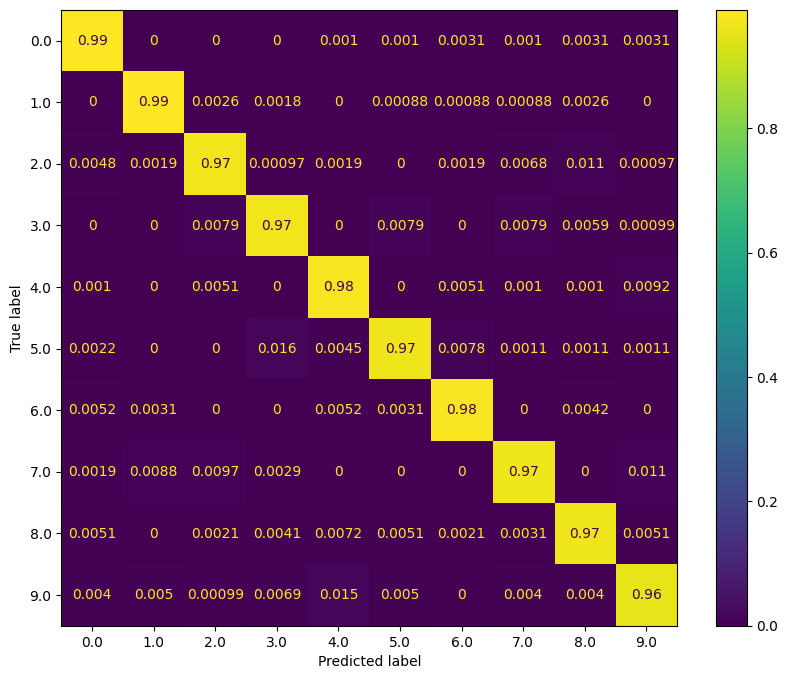

In [ ]:
visualizacion = metrics.ConfusionMatrixDisplay.from_predictions(arreglo_etiquetas, arreglo_predicciones,normalize='true')
figura = plt.gcf()
figura.set_figheight(8)
figura.set_figwidth(10)